In [ ]:
from scipy.io import loadmat
import networkx as nx
from scipy.sparse import csr_matrix
import warnings
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


# Load Graph

In [ ]:
def load_graph_from_mat(cur_file=None):
    # Load the MAT file
    mat = loadmat(cur_file)
    adjacency_matrix = mat['adj_matrix']
    sparse_matrix = csr_matrix(adjacency_matrix)
    G = nx.from_numpy_array(sparse_matrix)
    if not nx.is_connected(G):
            warnings.warn('The graph is not connected. \nLocatoin: ' + cur_file)
            subg = max(nx.connected_components(G), key=len)
            G = G.subgraph(subg)
            G = nx.convert_node_labels_to_integers(G)
    if len(G.nodes()) <= 10 or len(G.edges()) <= 100:
            warnings.warn('A graph is ignored because it has only a few nodes. \nLocatoin: ' + cur_file)
            return None
    return G

# ,mat file path
mat_file_path = "/home/zhangpeiyu/llm/interpretability_llm/compass/visualization/20kX_weighted_A_generated_/weighted_network_1.mat"
tif_path = "/home/zhangpeiyu/llm/interpretability_llm/compass/visualization/Copy of 300kV 20kX  Pre-GIF 2045.tif"
raw_src = cv2.imread(tif_path, cv2.IMREAD_GRAYSCALE)
w, h = raw_src.shape
if (h > w):
        scalefactor = 512 / h
else:
        scalefactor = 512 / w
swidth = int(scalefactor * w)
sheight = int(scalefactor * h)
dsize = (sheight, swidth)
src = cv2.resize(raw_src, dsize)

G = load_graph_from_mat(mat_file_path)
print(G)



Graph with 846 nodes and 1082 edges


# ForceAtlas

In [ ]:
def forceatlas_layout(G, iterations=100, k=1.0, gravity=1.0, scaling_ratio=1.0):
    pos = nx.spring_layout(G, iterations=50)  # pring_layout
    nodes = G.nodes()
    disp = {u: np.zeros(2) for u in nodes}

    for ii in tqdm(range(iterations)):
        # 计算排斥力
        for u in nodes:
            for v in nodes:
                if u != v:
                    delta = pos[u] - pos[v]
                    distance = np.linalg.norm(delta)
                    if distance > 0:
                        repulsive_force = scaling_ratio * (k * k) / distance
                        disp[u] += (delta / distance) * repulsive_force

        # 计算吸引力
        for u, v in G.edges():
            delta = pos[u] - pos[v]
            distance = np.linalg.norm(delta)
            if distance > 0:
                attractive_force = (distance * distance) / k
                disp[u] -= (delta / distance) * attractive_force
                disp[v] += (delta / distance) * attractive_force
                if ii>=6:

        # 应用重力
        for u in nodes:
            delta = pos[u]
            distance = np.linalg.norm(delta)
            if distance > 0:
                gravity_force = gravity * distance
                disp[u] -= (delta / distance) * gravity_force

        # 更新节点位置
        for u in nodes:
            pos[u] += disp[u]
            disp[u] = np.zeros(2)  # 重置位移

    return pos

In [ ]:
positions = forceatlas_layout(G, iterations=5, k=1.0, gravity=0.1, scaling_ratio=1.0)
x_values = [pos[0] for pos in positions.values()]
y_values = [pos[1] for pos in positions.values()]
max_x = max(x_values)
min_x = min(x_values)
max_y = max(y_values)
min_y = min(y_values)
print(positions)
f = plt.figure(figsize=(8.5, 8.5), dpi=400)
# plt.imshow(src, cmap='gray')
plt.imshow(src, cmap='gray',extent=[min_x, max_x, min_y, max_y])
nx.draw(G, with_labels=False, node_size=5, node_color="blue", edge_color="green",pos=positions)
# plt.draw()
# 使用matplotlib显示图形
plt.show()

# ForceAtlas2

In [ ]:
from fa2 import ForceAtlas2

forceatlas2 = ForceAtlas2(
    # Behavior alternatives
    outboundAttractionDistribution=True,  # Dissuade hubs
    linLogMode=False,  # NOT IMPLEMENTED
    adjustSizes=False,  # Prevent overlap (NOT IMPLEMENTED)
    edgeWeightInfluence=1.0,

    # Performance
    jitterTolerance=1.0,  # Tolerance
    barnesHutOptimize=True,
    barnesHutTheta=1.2,
    multiThreaded=False,  # NOT IMPLEMENTED

    # Tuning
    scalingRatio=2.0,
    strongGravityMode=False,
    gravity=1.0,

    # Log
    verbose=True)

# 计算节点的位置
# positions = forceatlas2.forceatlas2_networkx_layout(G, pos=None, iterations=2000)

In [ ]:
positions = np.load('/home/zhangpeiyu/llm/interpretability_llm/compass/visualization/20kX_postion.npy',allow_pickle=True)
positions[:, [0, 1]] = positions[:, [1, 0]]
pos_dict = {node: positions[i] for i, node in enumerate(G.nodes())}
positions = forceatlas2.forceatlas2_networkx_layout(G, pos=pos_dict, iterations=50)
min_x = min(positions.values(), key=lambda x: x[0])[0]
max_x = max(positions.values(), key=lambda x: x[0])[0]
min_y = min(positions.values(), key=lambda x: x[1])[1]
max_y = max(positions.values(), key=lambda x: x[1])[1]

def normalize(value, min_value, max_value):
    return 2 * (value - min_value) / (max_value - min_value) - 1

for node, (x, y) in positions.items():
    positions[node] = (normalize(x, min_x, max_x), normalize(y, min_y, max_y))

print(positions)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:04<00:00, 10.34it/s]

BarnesHut Approximation  took  0.59  seconds
Repulsion forces  took  3.97  seconds
Gravitational forces  took  0.04  seconds
Attraction forces  took  0.08  seconds
AdjustSpeedAndApplyForces step  took  0.10  seconds
{0: (-0.6786775858166942, -0.46158265428220124), 1: (-0.6672299054210304, -0.457476980563131), 2: (-0.5471172547856389, -0.6069205298702094), 3: (-0.03167180236956757, -0.5225180784466662), 4: (-0.13427622315735088, -0.7232608324646376), 5: (0.1918455989400938, -0.8216794703564716), 6: (-0.6112413012063582, -0.7656730596283978), 7: (-0.10861875743601712, -0.7540689912107192), 8: (0.009291815737093145, -0.6236295356773829), 9: (-0.1361456670822313, -0.7511892158270219), 10: (0.1998571078077116, -0.8251294389904034), 11: (-0.1853507838853543, -0.7036942827449475), 12: (-0.0773408754763023, -0.7871360341878981), 13: (-0.23876713741388667, -0.6098197894770572), 14: (0.669659323979825, -0.31771528044466546), 15: (-0.06944209706815685, -0.7519960035399249), 16: (-0.60770639068708

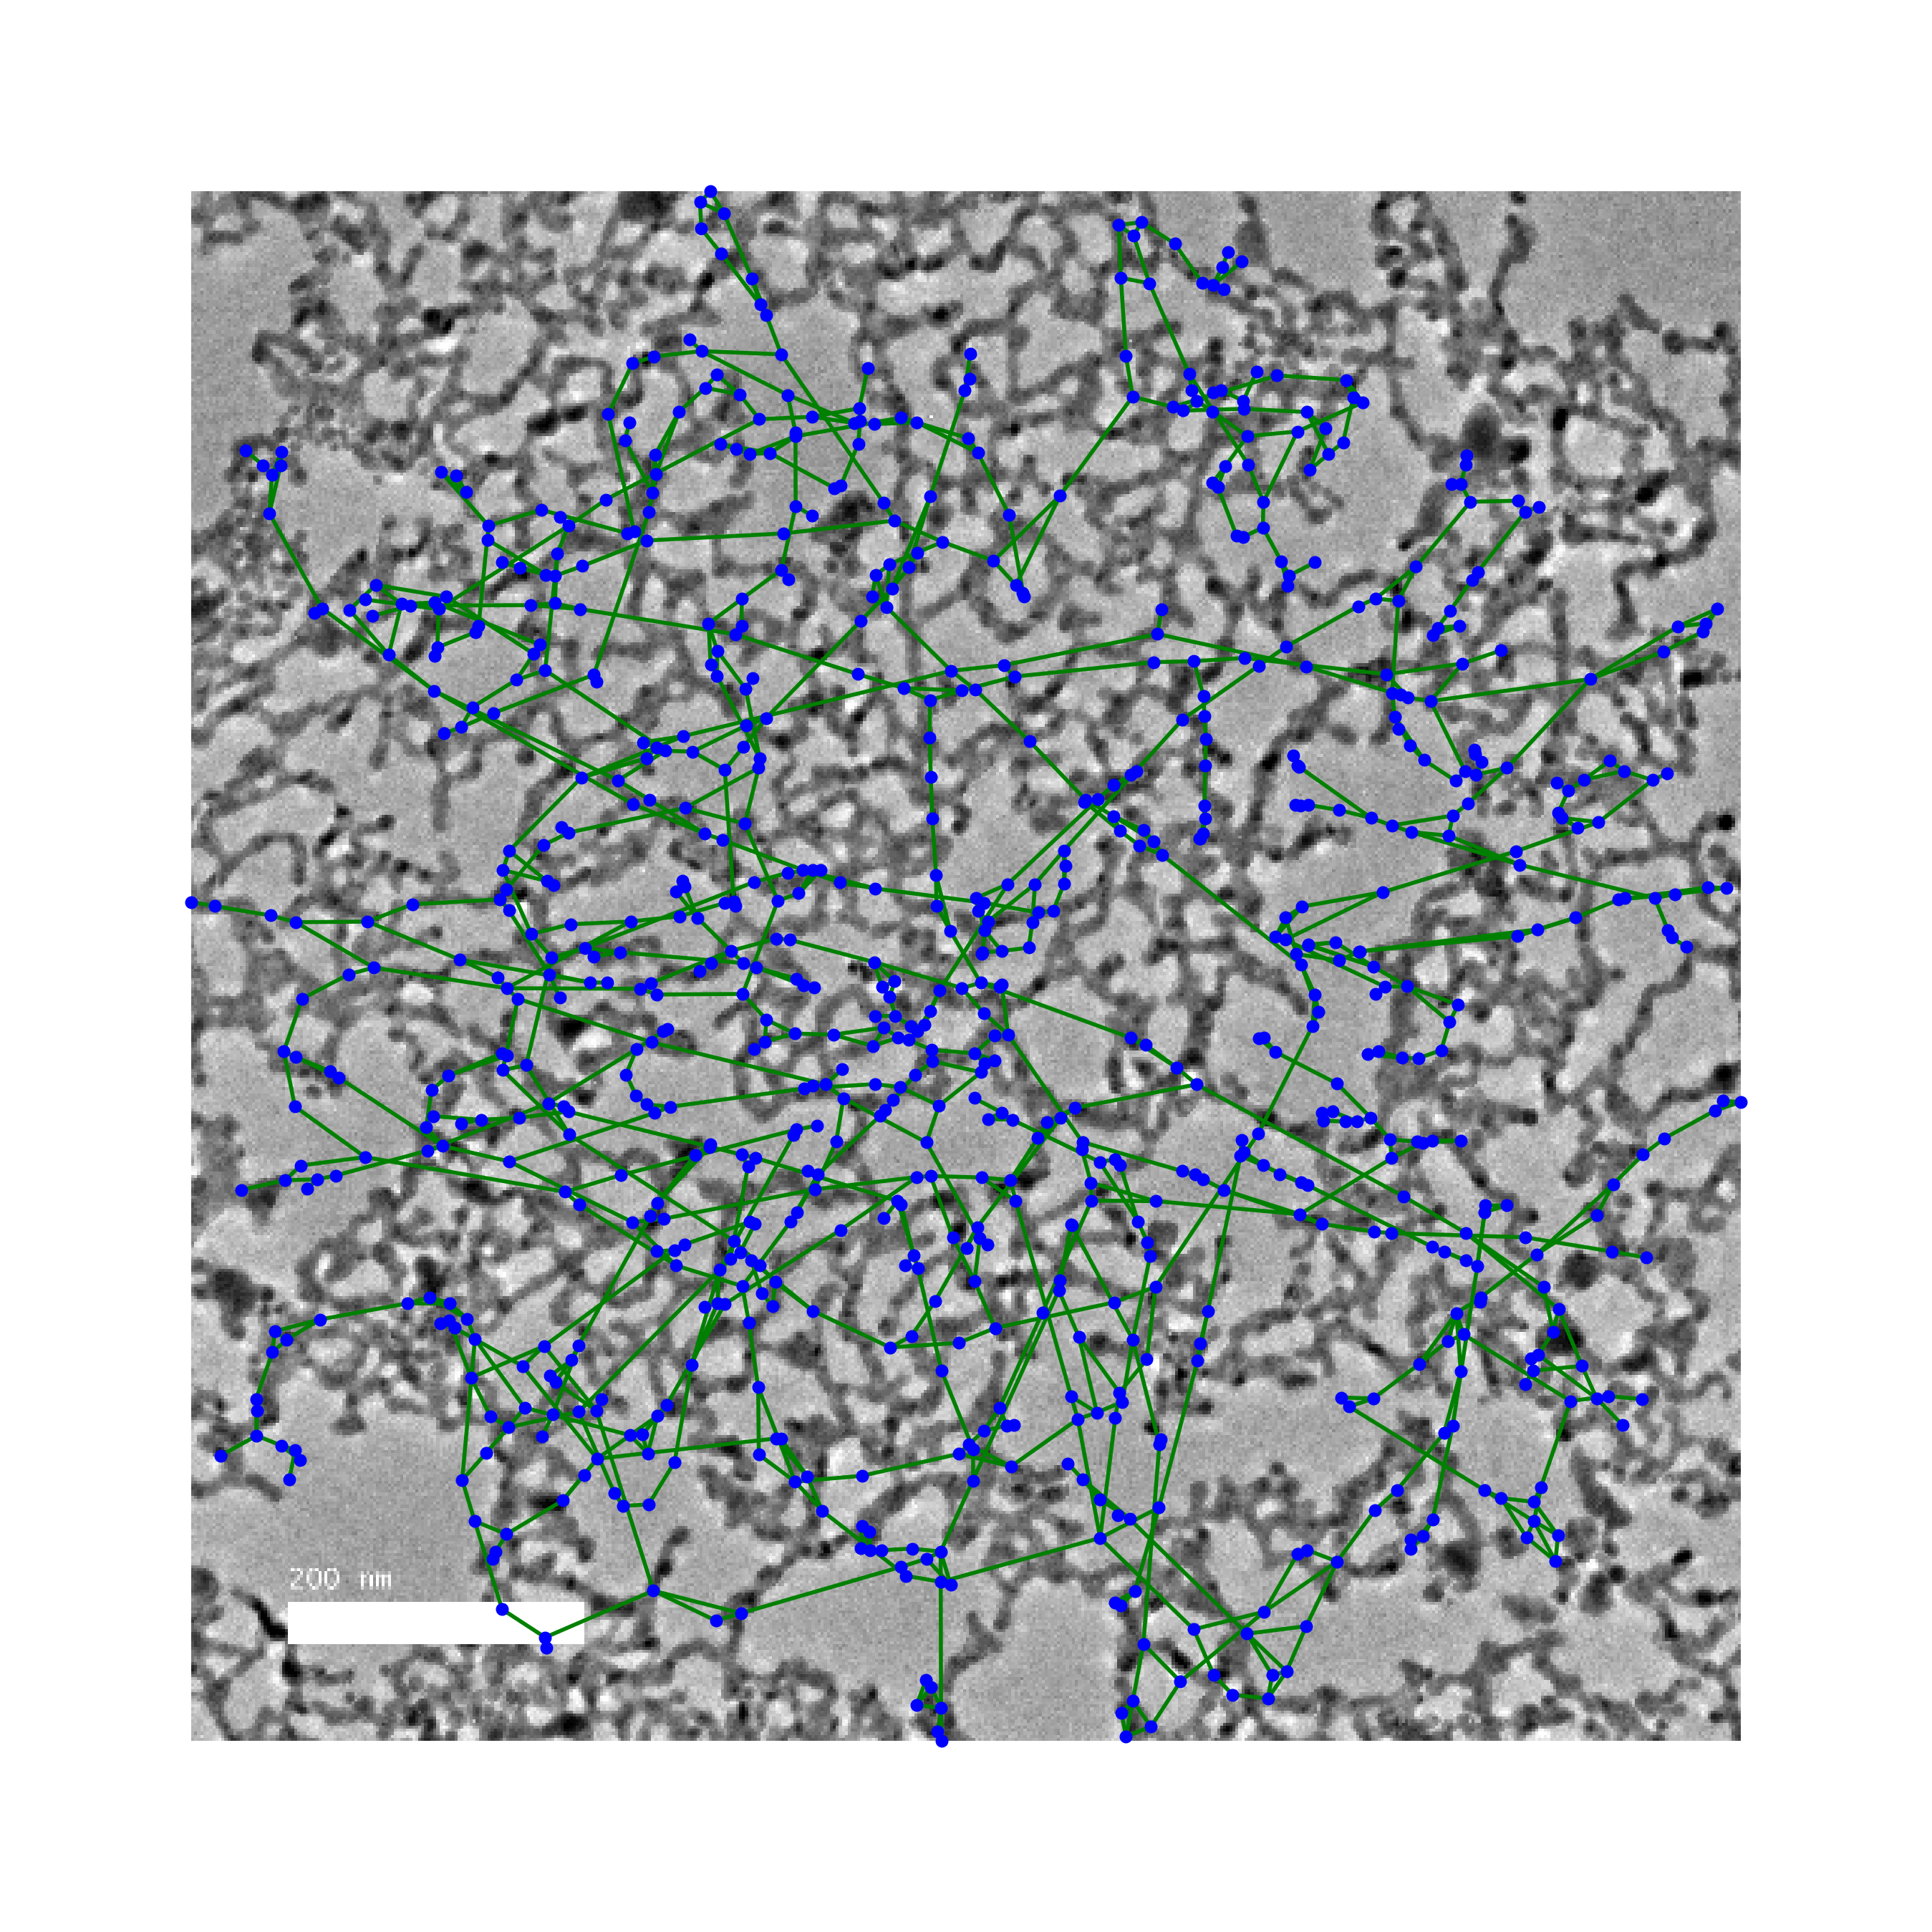

In [ ]:
# x_values = [pos[0] for pos in positions.values()]
# y_values = [pos[1] for pos in positions.values()]
# max_x = max(x_values)
# min_x = min(x_values)
# max_y = max(y_values)
# min_y = min(y_values)
f2 = plt.figure(figsize=(8.5, 8.5), dpi=400)
# plt.imshow(src, cmap='gray')
plt.imshow(src, cmap='gray',extent=[-1,1,-1,1])
nx.draw(G, with_labels=False, node_size=5, node_color="blue", edge_color="green",pos=positions)
# plt.draw()
# 使用matplotlib显示图形
plt.savefig('forceatlas2_vis.svg',bbox_inches = 'tight',dpi=400)

# spring_layout

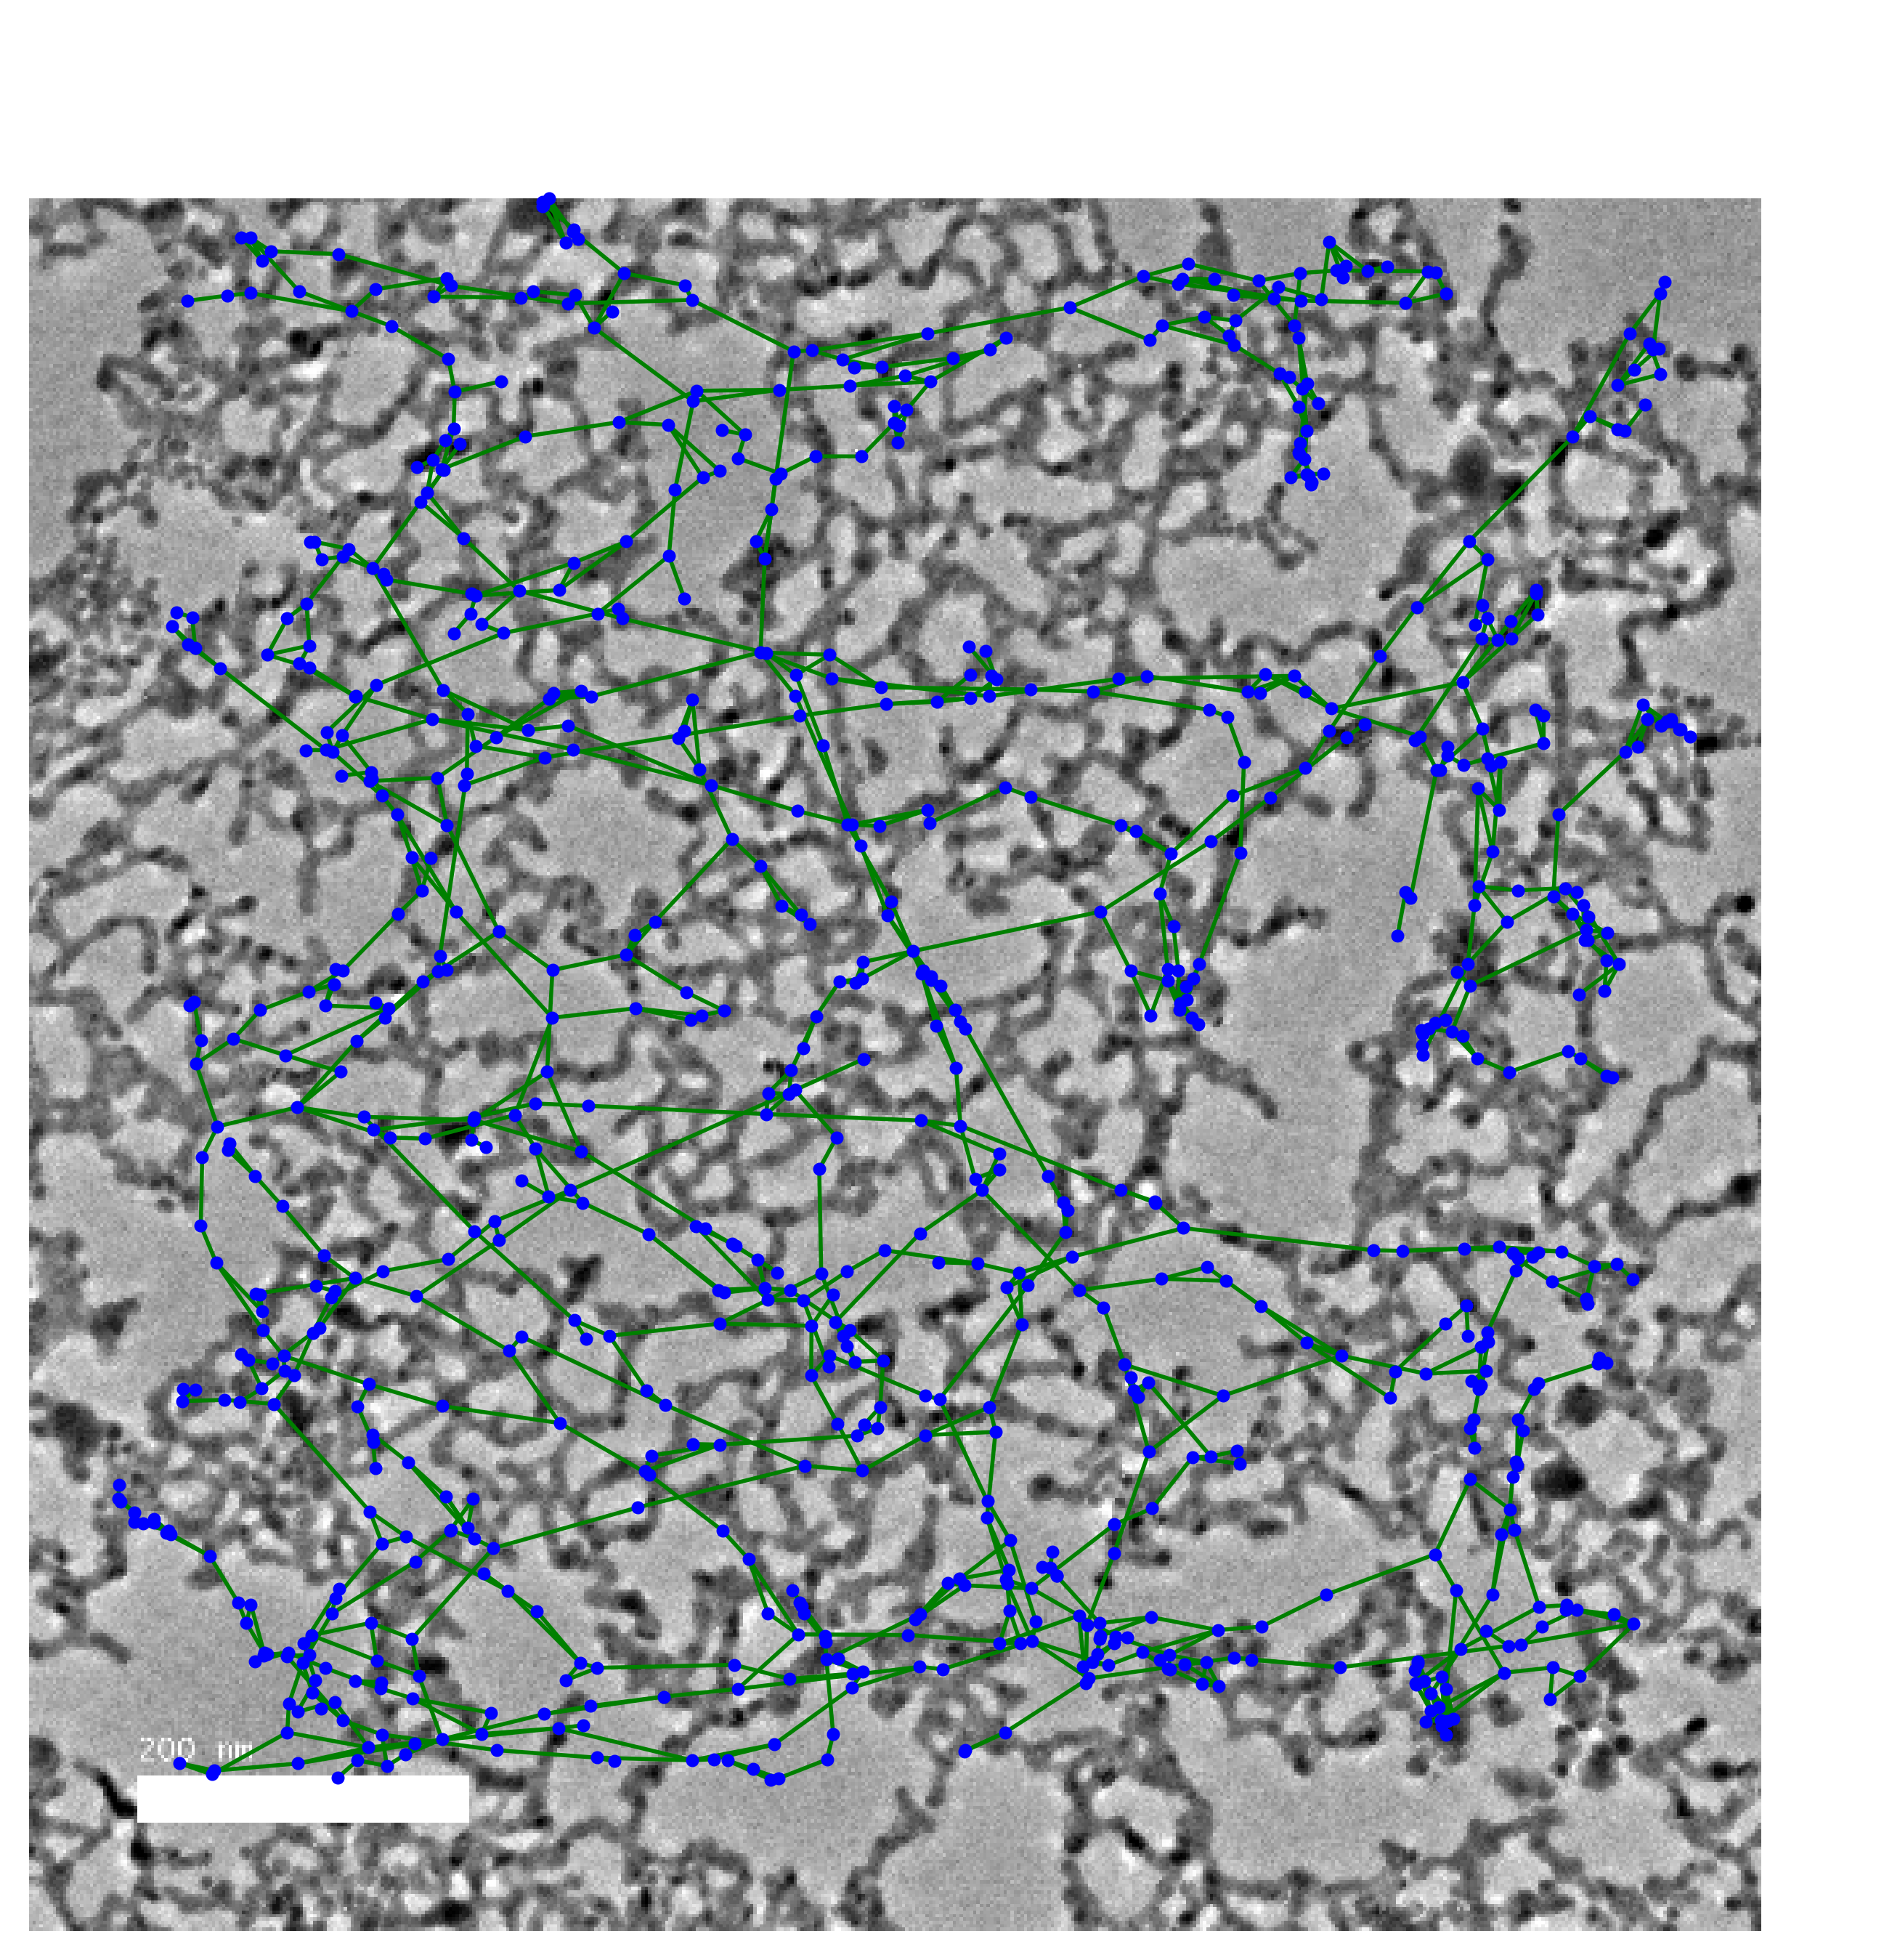

In [ ]:
f2 = plt.figure(figsize=(8.5, 8.5), dpi=400)
# plt.imshow(src, cmap='gray')
plt.imshow(src, cmap='gray',extent=[-1, 1, -1, 1])
nx.draw(G, with_labels=False, node_size=5, node_color="blue", edge_color="green",pos=nx.spring_layout(G, iterations=10,pos=pos_dict))
# plt.draw()
# 使用matplotlib显示图形
plt.savefig('spring_layout_vis.svg',bbox_inches = 'tight',dpi=400)

# kamada_kawai_layout

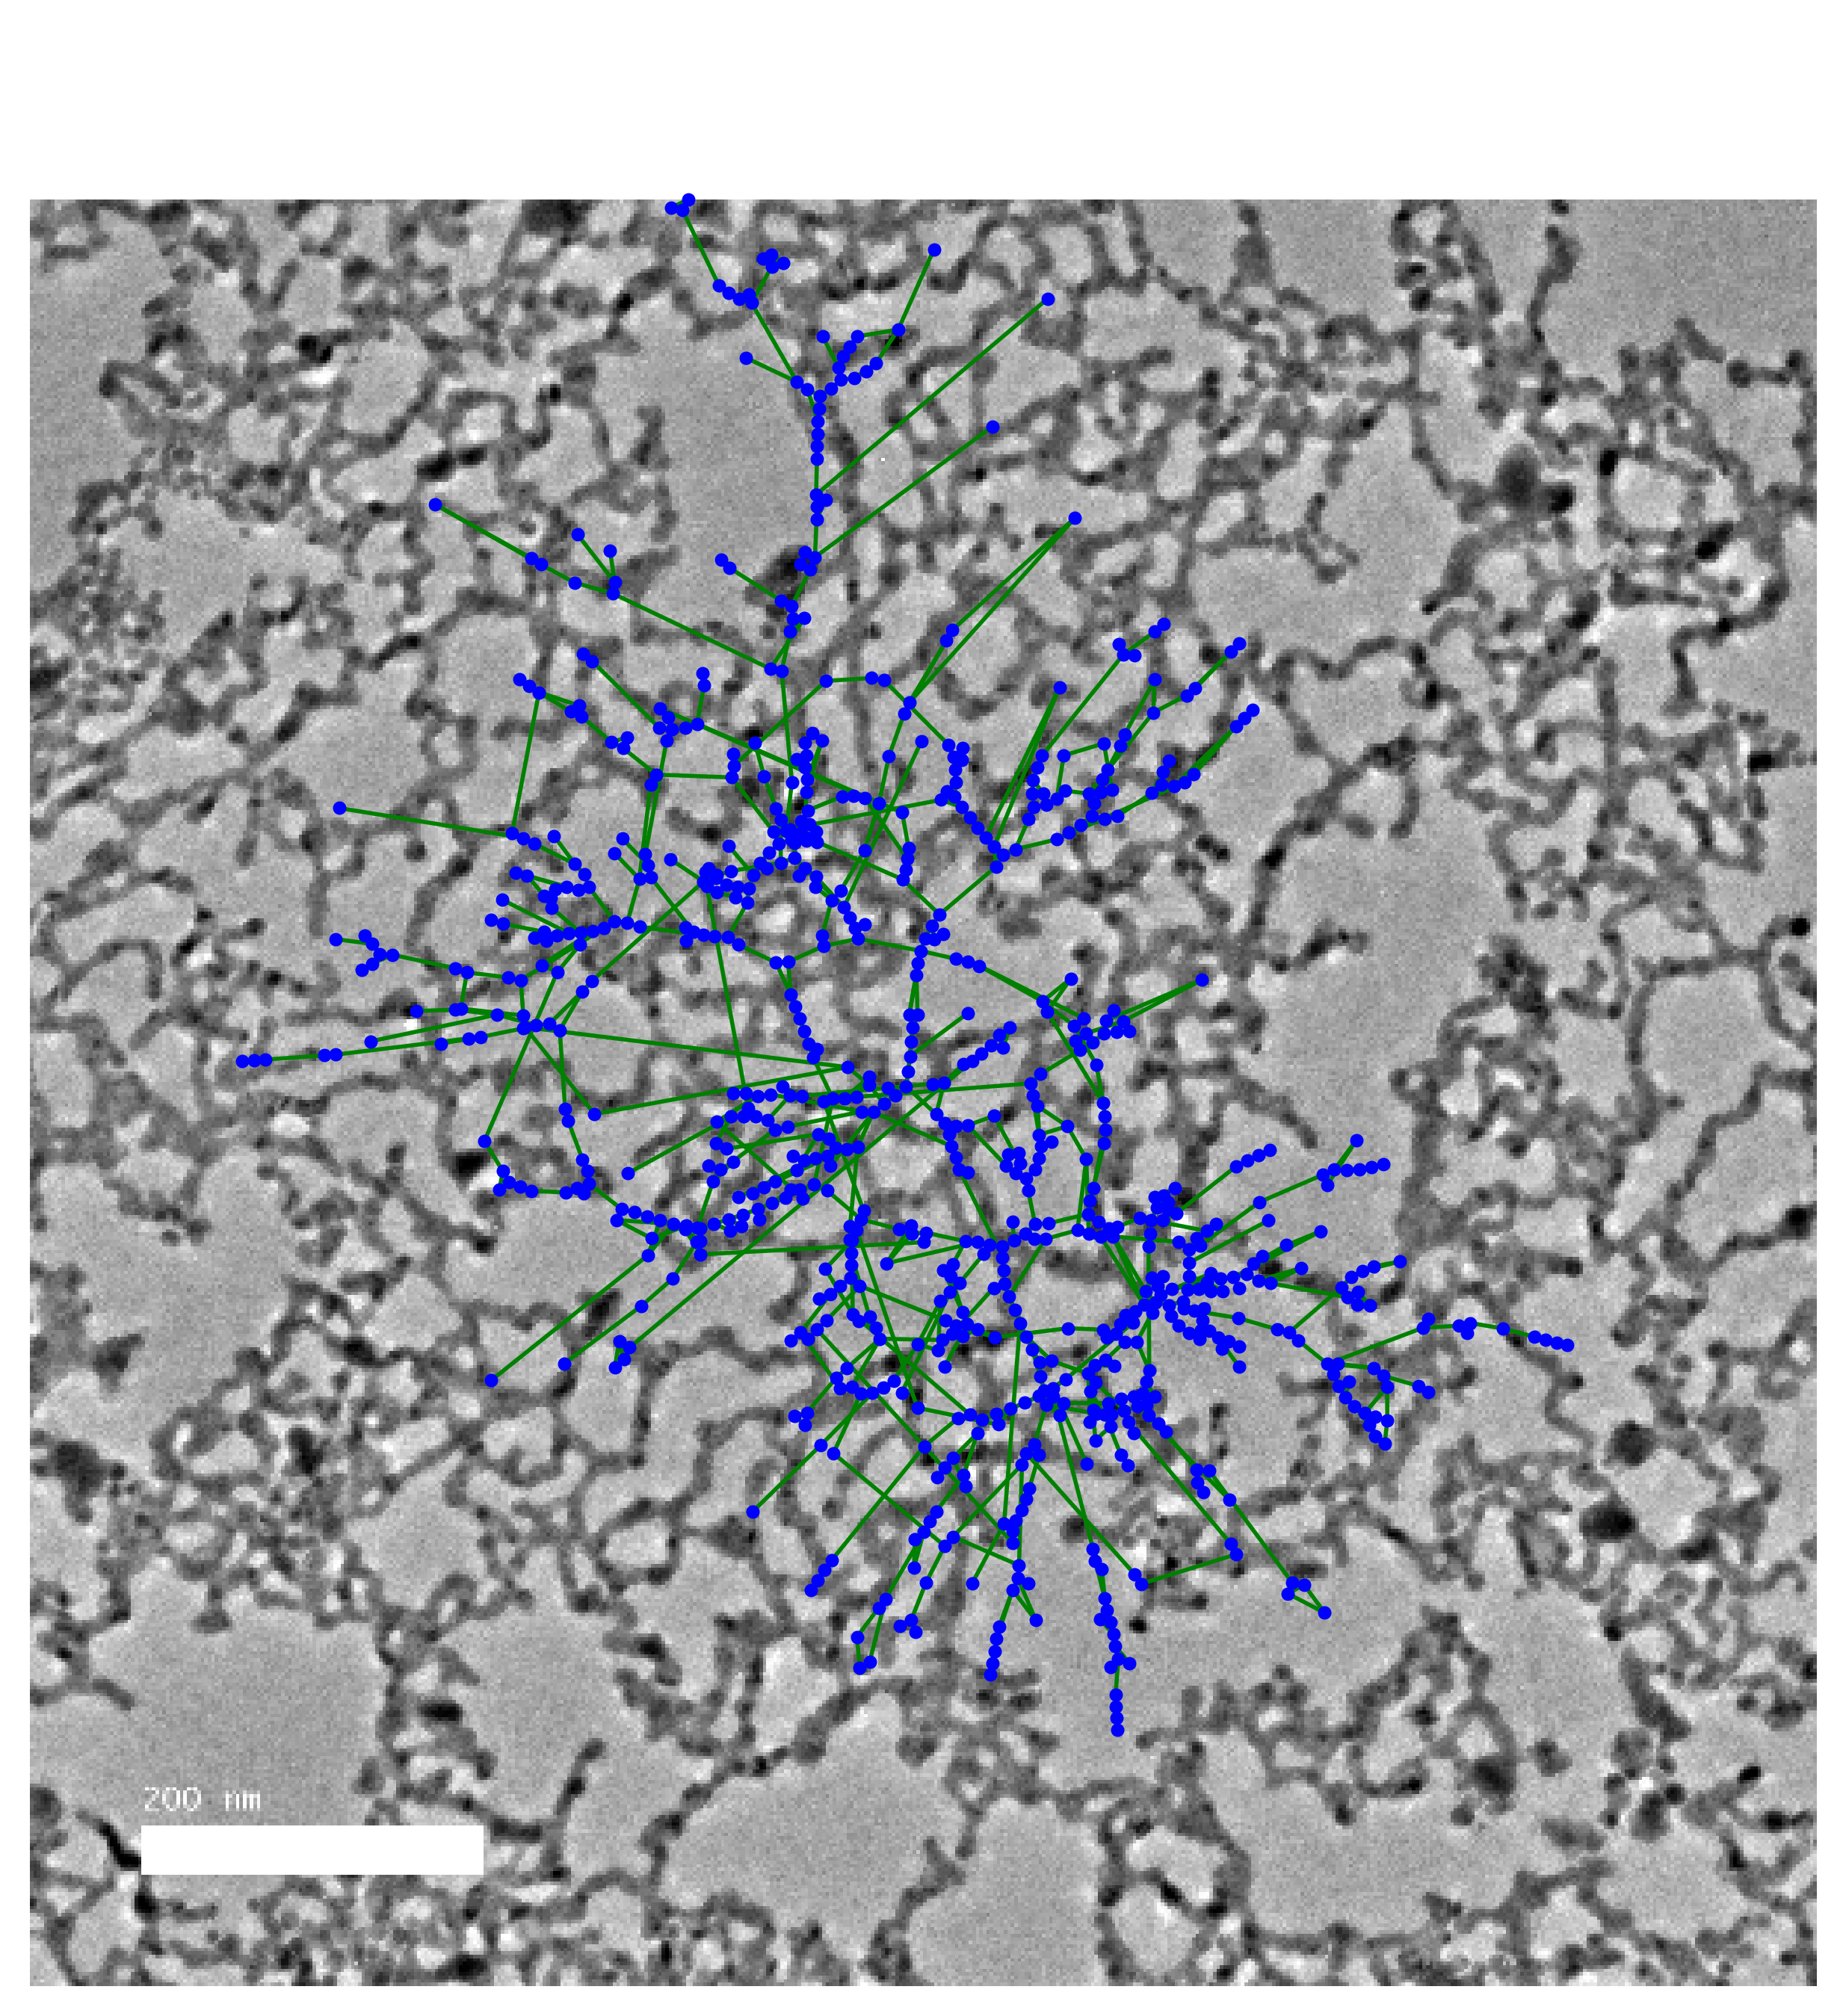

In [ ]:
f2 = plt.figure(figsize=(8.5, 8.5), dpi=400)
# plt.imshow(src, cmap='gray')
plt.imshow(src, cmap='gray',extent=[-1, 1, -1, 1])
nx.draw(G, with_labels=False, node_size=5, node_color="blue", edge_color="green",pos=nx.kamada_kawai_layout(G,pos=pos_dict))
# plt.draw()
# 使用matplotlib显示图形
plt.show()

# fruchterman_reingold_layout

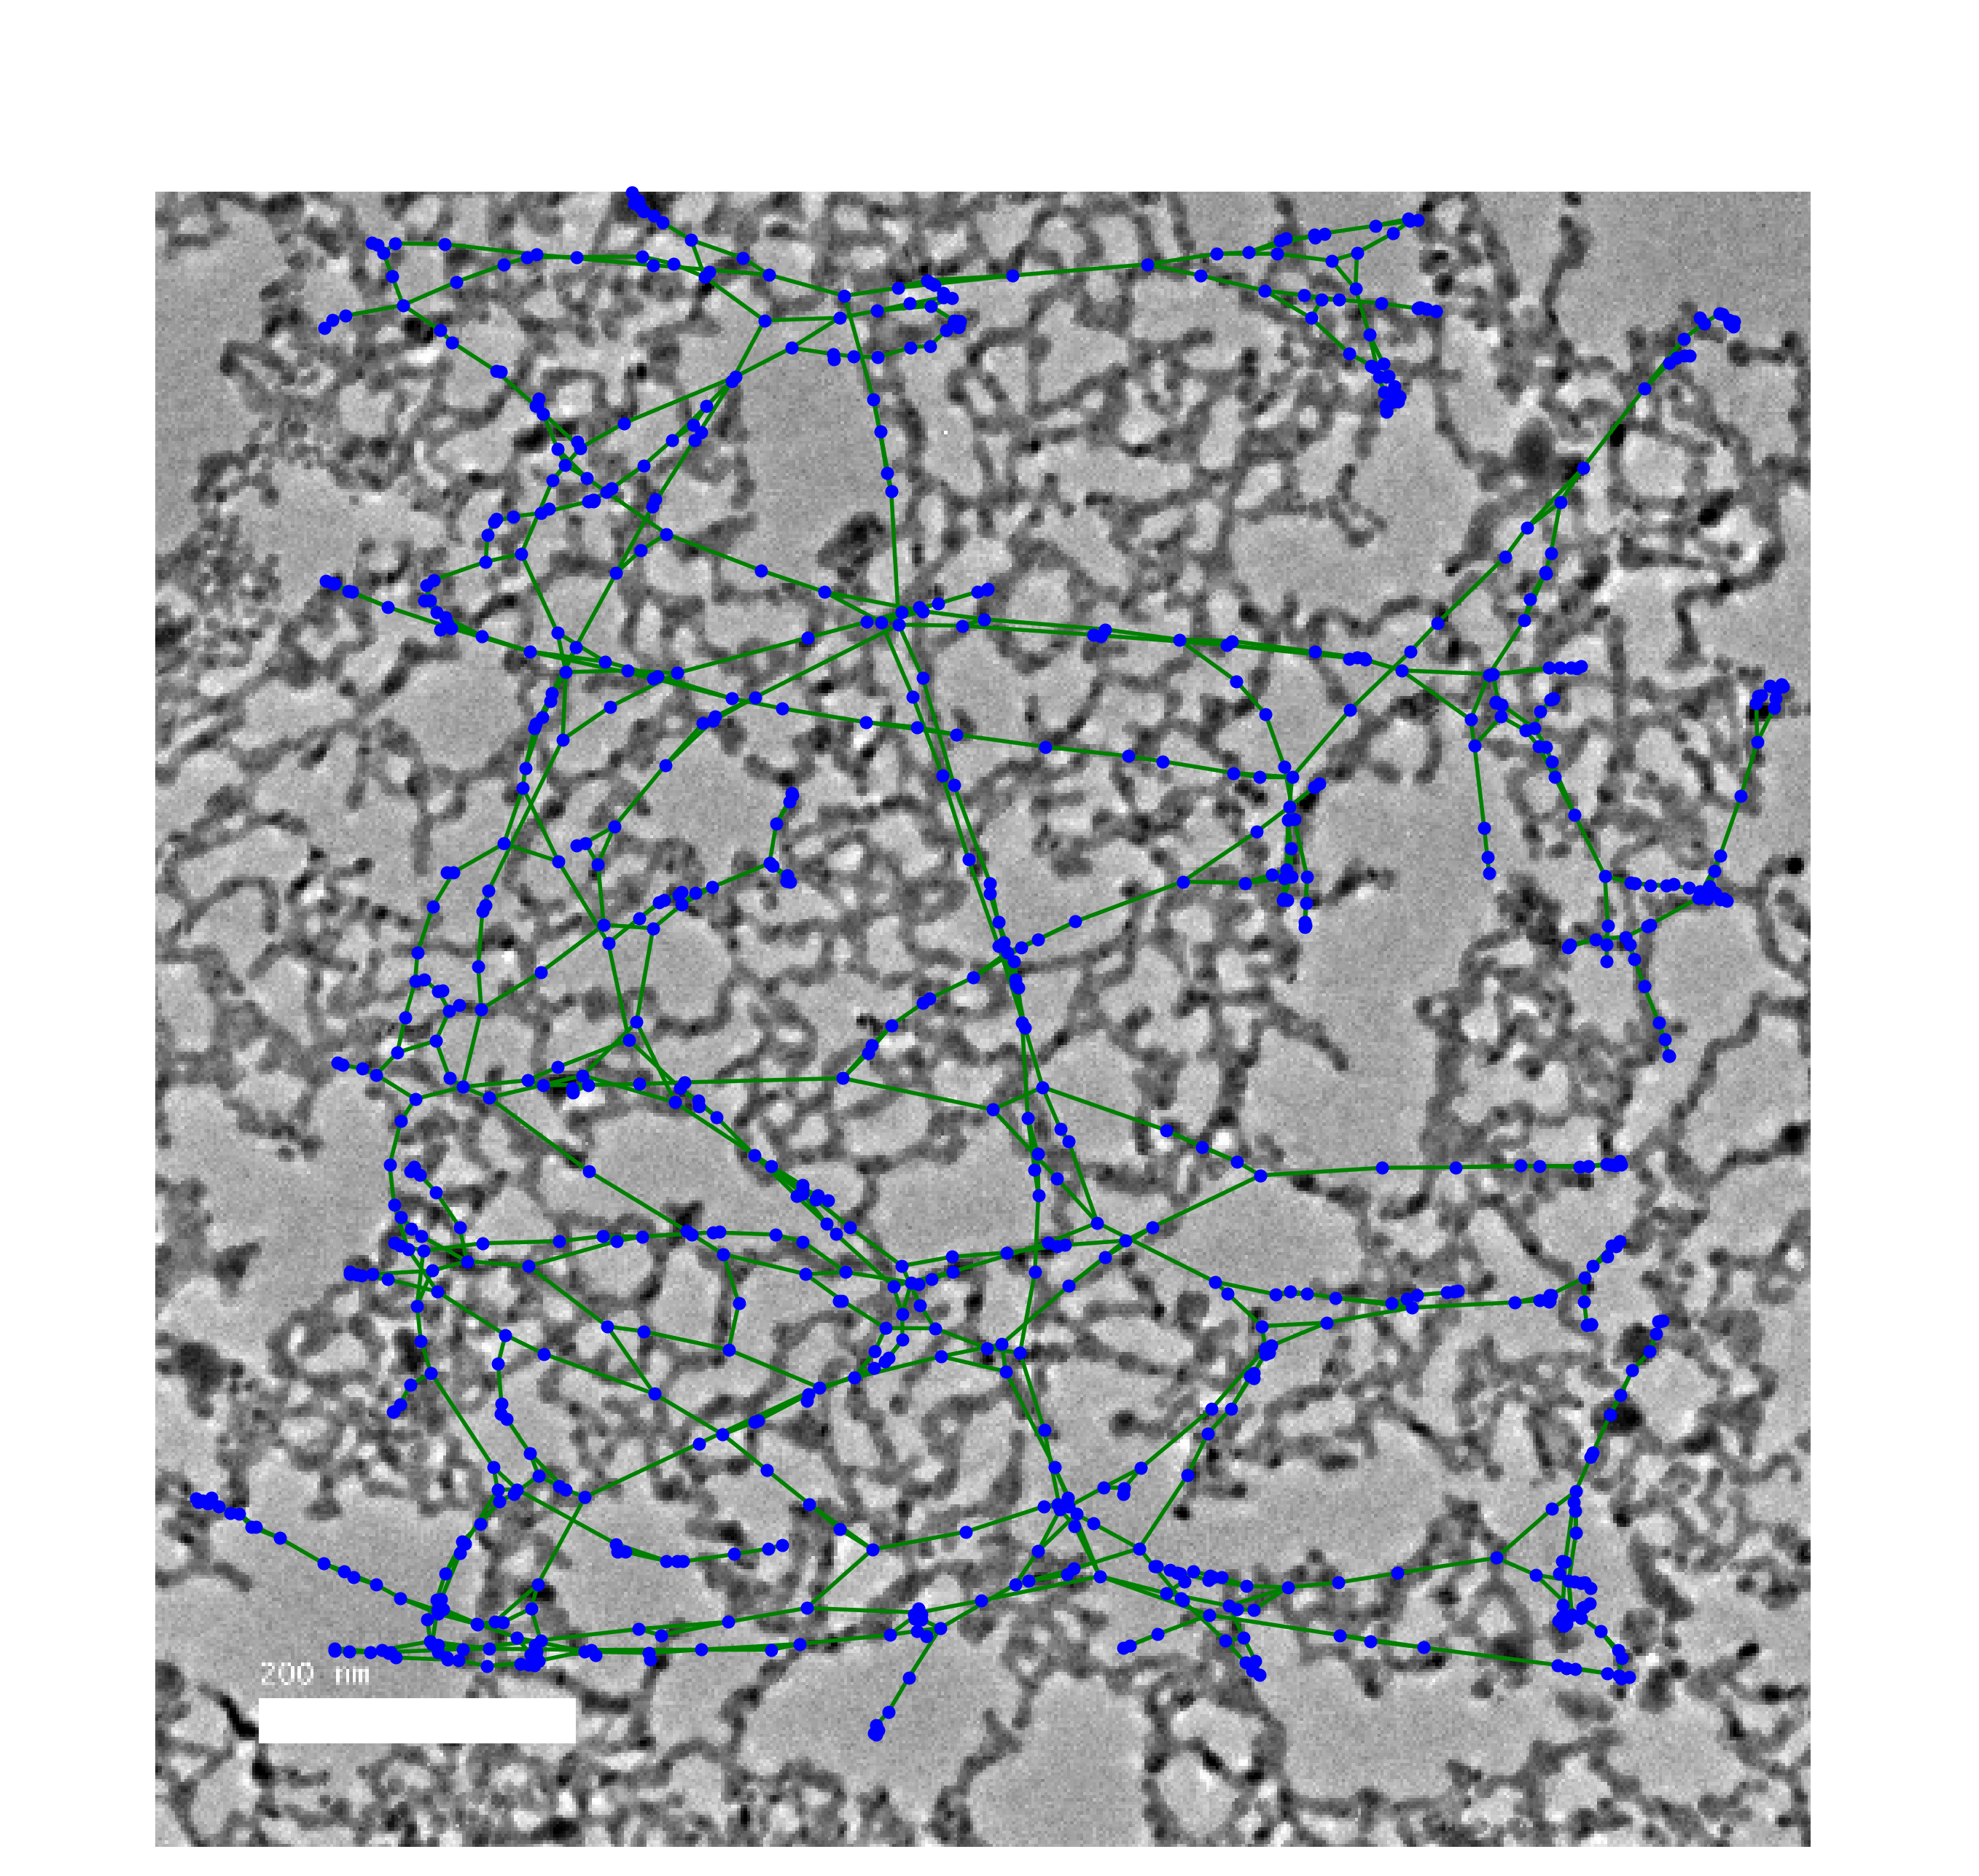

In [ ]:
f2 = plt.figure(figsize=(8.5, 8.5), dpi=400)
# plt.imshow(src, cmap='gray')
plt.imshow(src, cmap='gray',extent=[-1, 1, -1, 1])
nx.draw(G, with_labels=False, node_size=5, node_color="blue", edge_color="green",pos=nx.fruchterman_reingold_layout(G,pos=pos_dict))
# plt.draw()
# 使用matplotlib显示图形
plt.show()